In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import hierarchicalforecast
import statsforecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS

In [31]:
df_vendas = pd.read_parquet('../../data/gold/dataset_vendas.parquet')
df_vendas.head()

,week_date,year,semester,quarter,month,units_sold,region_name,product_attribute_1,product_attribute_2,product_attribute_3,product_name,supplier_name
0,2022-10-31,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
1,2022-11-07,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
2,2022-11-14,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
3,2022-11-21,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
4,2022-11-28,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6


In [32]:
n_weeks = len(df_vendas['week_date'].unique())
n_products = len(df_vendas['product_name'].unique())
n_suppliers = len(df_vendas['supplier_name'].unique())
print(f'Número de semanas: {n_weeks}')
print(f'Número de produtos: {n_products}')
print(f'Número de fornecedores: {n_suppliers}')

Número de semanas: 104
Número de produtos: 390
Número de fornecedores: 27


In [33]:
#drop empty timeseries
df_vendas['is_zero'] = df_vendas['units_sold'].apply(lambda x: 1 if x == 0 else 0)
index_zeros = df_vendas.groupby(['supplier_name','region_name','product_name']).agg({'is_zero':'sum'}).reset_index().query('is_zero == 104')[['supplier_name','region_name','product_name']]
df_vendas = df_vendas.merge(index_zeros, on=['supplier_name','region_name','product_name'], how='left', indicator=True).query('_merge == "left_only"').drop(columns=['_merge','is_zero'])
df_vendas

C:\Users\eduar\AppData\Local\Temp\ipykernel_14584\267713160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index_zeros = df_vendas.groupby(['supplier_name','region_name','product_name']).agg({'is_zero':'sum'}).reset_index().query('is_zero == 104')[['supplier_name','region_name','product_name']]


,week_date,year,semester,quarter,month,units_sold,region_name,product_attribute_1,product_attribute_2,product_attribute_3,product_name,supplier_name
0,2022-10-31,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
1,2022-11-07,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
2,2022-11-14,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
3,2022-11-21,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
4,2022-11-28,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
...,...,...,...,...,...,...,...,...,...,...,...,...
295875,2024-09-23,2024,2,3,9,0.0,Centro-Oeste,C,B,B04,Product 36,Supplier 6
295876,2024-09-30,2024,2,3,9,6.0,Centro-Oeste,C,B,B04,Product 36,Supplier 6
295877,2024-10-07,2024,2,4,10,2.0,Centro-Oeste,C,B,B04,Product 36,Supplier 6
295878,2024-10-14,2024,2,4,10,6.0,Centro-Oeste,C,B,B04,Product 36,Supplier 6


In [34]:
df_vendas['is_zero'] = df_vendas['units_sold'].apply(lambda x: 1 if x == 0 else 0)
df_vendas.groupby(['supplier_name','region_name','product_name']).agg({'is_zero':'sum'}).sort_values('is_zero', ascending=False).head(10)

C:\Users\eduar\AppData\Local\Temp\ipykernel_14584\3552245827.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vendas.groupby(['supplier_name','region_name','product_name']).agg({'is_zero':'sum'}).sort_values('is_zero', ascending=False).head(10)


,,,is_zero
supplier_name,region_name,product_name,
Supplier 6,Nordeste,Product 14,103
Supplier 16,Norte,Product 219,103
Supplier 6,Nordeste,Product 28,103
Supplier 15,Centro-Oeste,Product 216,103
Supplier 22,Sudeste,Product 185,103
Supplier 14,Nordeste,Product 215,103
Supplier 6,Sul,Product 137,103
Supplier 8,Norte,Product 19,103
Supplier 3,Nordeste,Product 245,103


<Axes: xlabel='week_date'>

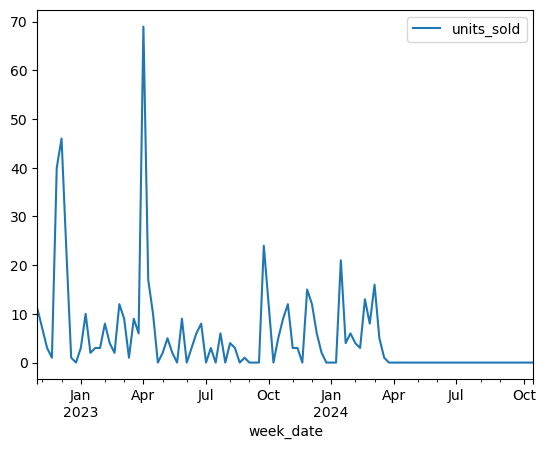

In [35]:
df_vendas[(df_vendas['supplier_name'] == 'Supplier 15') & (df_vendas['region_name'] == 'Sudeste') & (df_vendas['product_name'] == 'Product 258')][['week_date','units_sold']].plot(x='week_date', y='units_sold', kind='line')  

<Axes: xlabel='week_date'>

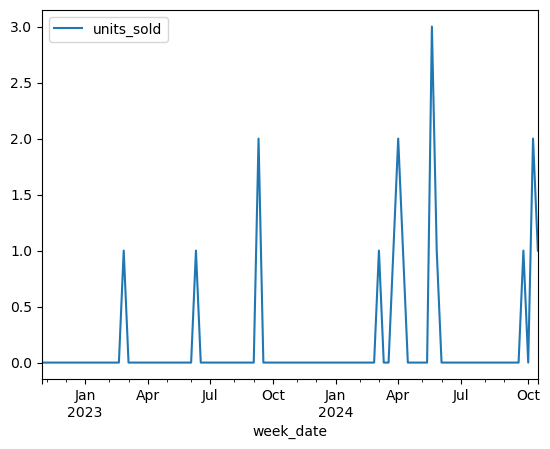

In [36]:
df_vendas[(df_vendas['supplier_name'] == 'Supplier 6') & (df_vendas['region_name'] == 'Sudeste') & (df_vendas['product_name'] == 'Product 221')][['week_date','units_sold']].set_index('week_date').plot()

In [ ]:
df_vendas[(df_vendas['supplier_name'] == 'Supplier 15') & (df_vendas['region_name'] == 'Sudeste') & (df_vendas['product_name'] == 'Product 258')][['week_date','units_sold']].plot(x='week_date', y='units_sold', kind='line')  

In [37]:
df_vendas.groupby('week_date')['units_sold'].sum().head(50)

week_date
2022-10-31    114581.0
2022-11-07     64134.0
2022-11-14     68566.0
2022-11-21     39839.0
2022-11-28     88060.0
2022-12-05     75696.0
2022-12-12     62304.0
2022-12-19     54763.0
2022-12-26     54097.0
2023-01-02     56952.0
2023-01-09     56733.0
2023-01-16     62554.0
2023-01-23     30822.0
2023-01-30    106439.0
2023-02-06     65540.0
2023-02-13     55488.0
2023-02-20     33556.0
2023-02-27    115152.0
2023-03-06     71110.0
2023-03-13     77626.0
2023-03-20     79519.0
2023-03-27     67283.0
2023-04-03     69506.0
2023-04-10     61392.0
2023-04-17     83935.0
2023-04-24      2601.0
2023-05-01    141856.0
2023-05-08     78464.0
2023-05-15     77168.0
2023-05-22     49890.0
2023-05-29    112537.0
2023-06-05     80795.0
2023-06-12     82739.0
2023-06-19     86459.0
2023-06-26     99987.0
2023-07-03     53338.0
2023-07-10     46171.0
2023-07-17     51006.0
2023-07-24    191231.0
2023-07-31     77255.0
2023-08-07     42431.0
2023-08-14     34465.0
2023-08-21     88313.0
2

<Axes: xlabel='week_date'>

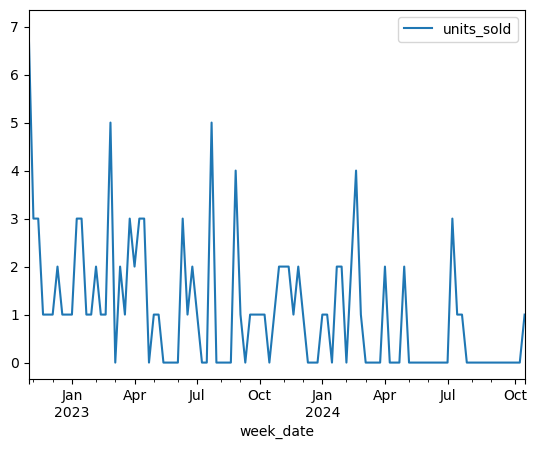

In [45]:
df_vendas[df_vendas['product_name'] == 'Product 1'].groupby(['week_date']).agg({'units_sold':'sum'}).plot(y='units_sold', kind='line')